In [1]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

In [2]:
# ============================================================
# STEP 2: LOAD BRENT DAILY DATASET
# ============================================================

# Change path according to your dataset

brent_daily = pd.read_csv(
    "cleaned_datasets/brent_daily_clean.csv"
)


print(brent_daily.head())

print(brent_daily.info())

         Date  Price
0  1987-05-20  18.63
1  1987-05-21  18.45
2  1987-05-22  18.55
3  1987-05-25  18.60
4  1987-05-26  18.63
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9922 entries, 0 to 9921
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9922 non-null   object 
 1   Price   9922 non-null   float64
dtypes: float64(1), object(1)
memory usage: 155.2+ KB
None


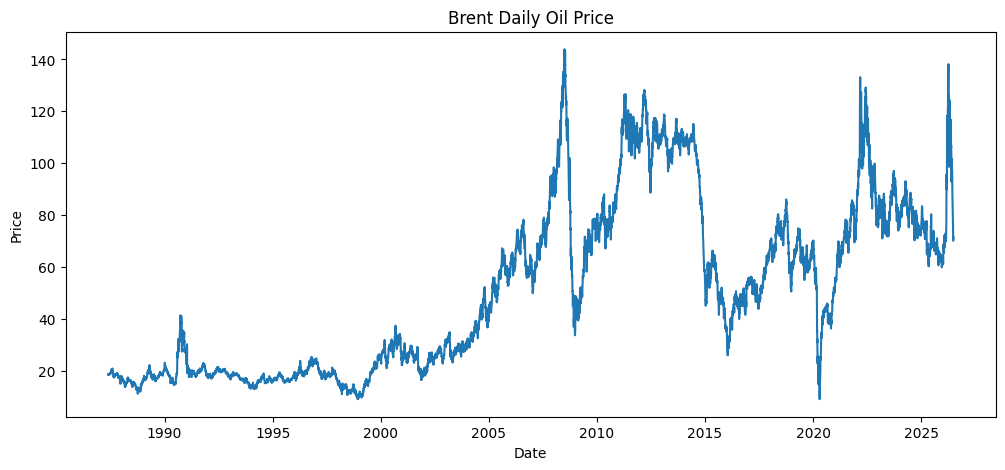

In [3]:
# ============================================================
# STEP 3: DATA PREPROCESSING
# ============================================================


# Convert date column

brent_daily['Date'] = pd.to_datetime(
    brent_daily['Date']
)


# Sort data by date

brent_daily = brent_daily.sort_values(
    'Date'
)


# Set date as index

brent_daily.set_index(
    'Date',
    inplace=True
)



# Select target variable
# Change "Price" if your column name is different

oil = brent_daily[['Price']]


# Visualize data

plt.figure(figsize=(12,5))

plt.plot(
    oil
)

plt.title(
    "Brent Daily Oil Price"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Price"
)

plt.show()

In [4]:
# ============================================================
# STEP 4: FEATURE ENGINEERING FOR XGBOOST
# ============================================================

# Create lag features
# Previous days' prices become predictors

data = oil.copy()


# Lag values

data['Lag_1'] = data['Price'].shift(1)

data['Lag_2'] = data['Price'].shift(2)

data['Lag_3'] = data['Price'].shift(3)

data['Lag_7'] = data['Price'].shift(7)

data['Lag_14'] = data['Price'].shift(14)

data['Lag_30'] = data['Price'].shift(30)



# Rolling statistics

data['Rolling_Mean_7'] = (
    data['Price']
    .rolling(window=7)
    .mean()
)


data['Rolling_Mean_30'] = (
    data['Price']
    .rolling(window=30)
    .mean()
)



# Rolling standard deviation (volatility)

data['Rolling_STD_7'] = (
    data['Price']
    .rolling(window=7)
    .std()
)



# Remove missing values created by lagging

data.dropna(
    inplace=True
)



print(data.head())

            Price  Lag_1  Lag_2  Lag_3  Lag_7  Lag_14  Lag_30  Rolling_Mean_7  \
Date                                                                            
1987-07-02  19.25  18.98  19.08  19.15  18.90   18.68   18.63       18.998571   
1987-07-03  19.33  19.25  18.98  19.08  18.75   18.78   18.45       19.081429   
1987-07-06  19.48  19.33  19.25  18.98  18.70   18.90   18.55       19.192857   
1987-07-07  19.50  19.48  19.33  19.25  19.08   19.03   18.60       19.252857   
1987-07-08  19.48  19.50  19.48  19.33  19.15   19.05   18.63       19.300000   

            Rolling_Mean_30  Rolling_STD_7  
Date                                        
1987-07-02        18.810333       0.204404  
1987-07-03        18.839667       0.204404  
1987-07-06        18.870667       0.171825  
1987-07-07        18.900667       0.197291  
1987-07-08        18.929000       0.207766  


In [5]:
# ============================================================
# STEP 5: DEFINE FEATURES AND TARGET
# ============================================================


X = data.drop(
    'Price',
    axis=1
)


y = data['Price']

In [6]:
# ============================================================
# STEP 6: TRAIN TEST SPLIT
# ============================================================

# Time series split
# No random shuffle

train_size = int(
    len(data) * 0.8
)


X_train = X.iloc[:train_size]

X_test = X.iloc[train_size:]


y_train = y.iloc[:train_size]

y_test = y.iloc[train_size:]


print(
    X_train.shape,
    X_test.shape
)

(7913, 9) (1979, 9)


In [7]:
# ============================================================
# STEP 7: BUILD XGBOOST REGRESSION MODEL
# ============================================================


xgb_model = XGBRegressor(

    n_estimators=500,

    learning_rate=0.01,

    max_depth=5,

    subsample=0.8,

    colsample_bytree=0.8,

    objective='reg:squarederror',

    random_state=42

)

In [8]:

# ============================================================
# STEP 8: TRAIN MODEL
# ============================================================


xgb_model.fit(

    X_train,

    y_train

)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
# ============================================================
# STEP 9: MAKE PREDICTIONS
# ============================================================


predictions = xgb_model.predict(
    X_test
)

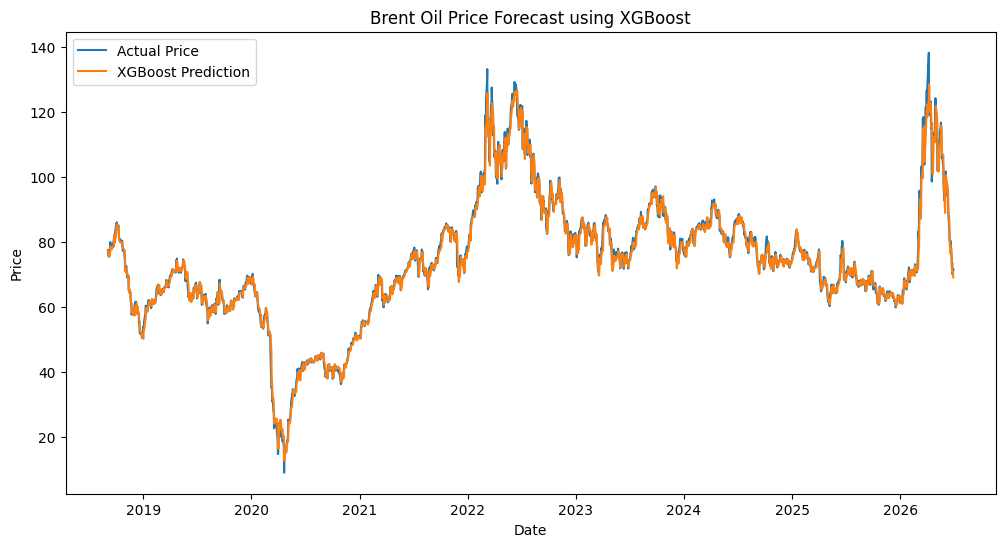

In [10]:
# ============================================================
# STEP 10: VISUALIZE ACTUAL VS PREDICTED
# ============================================================


plt.figure(figsize=(12,6))


plt.plot(
    y_test.index,
    y_test,
    label="Actual Price"
)


plt.plot(
    y_test.index,
    predictions,
    label="XGBoost Prediction"
)


plt.title(
    "Brent Oil Price Forecast using XGBoost"
)


plt.xlabel(
    "Date"
)


plt.ylabel(
    "Price"
)


plt.legend()

plt.show()

In [11]:
# ============================================================
# STEP 11: MODEL EVALUATION
# ============================================================


# MAE

mae = mean_absolute_error(
    y_test,
    predictions
)



# RMSE

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)



# MAPE

mape = np.mean(

    np.abs(
        (y_test - predictions)
        /
        y_test
    )

) * 100

print("==============================")
print("XGBOOST MODEL PERFORMANCE")
print("==============================")


print(
    "MAE:",
    mae
)


print(
    "RMSE:",
    rmse
)


print(
    "MAPE:",
    mape,
    "%"
)


XGBOOST MODEL PERFORMANCE
MAE: 1.4501719990518736
RMSE: 2.1766548633351133
MAPE: 2.0594986590270237 %


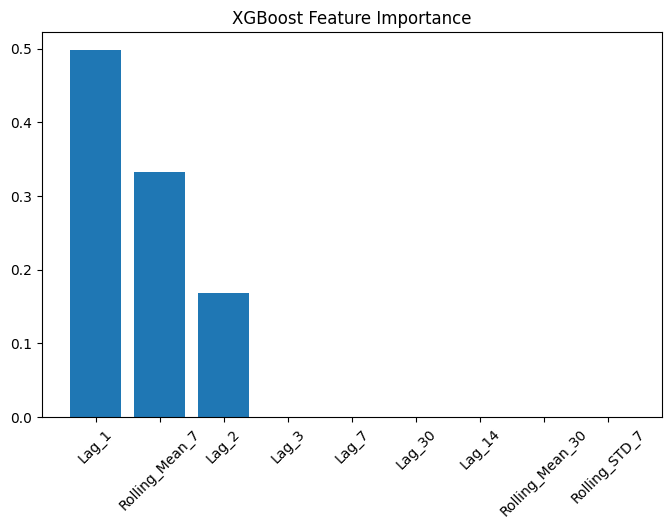

In [12]:
# ============================================================
# STEP 12: FEATURE IMPORTANCE
# ============================================================


importance = pd.DataFrame(

    {
        'Feature': X.columns,

        'Importance': xgb_model.feature_importances_

    }

)


importance = importance.sort_values(
    by='Importance',
    ascending=False
)



plt.figure(figsize=(8,5))


plt.bar(

    importance['Feature'],

    importance['Importance']

)


plt.xticks(
    rotation=45
)


plt.title(
    "XGBoost Feature Importance"
)


plt.show()


In [13]:
# ============================================================
# STEP 13: SAVE MODEL
# ============================================================


xgb_model.save_model(
    "brent_daily_xgboost_model.json"
)


print("XGBoost model saved successfully!")

XGBoost model saved successfully!
